In [2]:
#imports

from astropy.io import fits #for fits image handeling


In [54]:
#load 2d data

fits_2d = 'data/2d/NGC253_ArIII_9.0_moment0.fits' #assigning file name
hdul = fits.open(fits_2d)  #opening file with fits.open

hdul.info() #reading file informations to understand it 
#hdul.close() To close the file

hdr = hdul[0].header #so now hdr is astropy's header object
#print(repr(hdr)) #print full header
#list(hdr.keys()) #list the keys of header



Filename: data/2d/NGC253_ArIII_9.0_moment0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCI           1 PrimaryHDU      95   (75, 97)   float32   


In [18]:
#---This should be the preferred way after knowing header---
# instead of using [1] or [2]
# remember the pain while smoothing 
# assigning values to data
data = hdul['SCI'].data  

data.shape #understand dimension of data
data.dtype.name #understand data type
print(data[37,47]) #printing value at specificc pixel

1678.6626


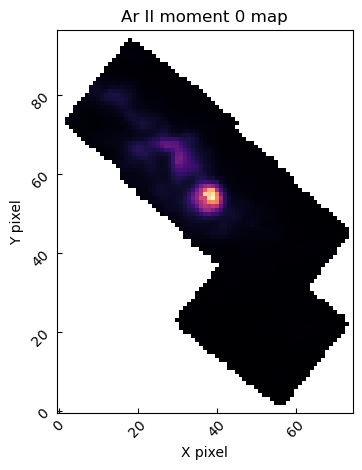

In [56]:
# More costumization will be used in my matplotlib tutorial file 

#import matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots() #i love this i will always use this as i can do subplots
plt.imshow(data, origin='lower', cmap='magma') #because it is image
# --- Oh I love costumization ---# 
ax.set_title('Ar II moment 0 map', fontsize=12)
ax.set_xlabel('X pixel', fontsize = 10)
ax.set_ylabel('Y pixel', fontsize = 10)

#ax.grid(True) # we often dont use this

# lets play with ticks
ax.tick_params( axis = 'both',
                direction ='in',
                labelsize = 10,
                labelrotation = 45,
              )
# The above wont work with WCS stuffs like rotations we will use ax.coords[0] or so later for that

plt.tight_layout()
plt.show() #display plot

In [63]:
# Lets manupulate the fits file
print(data[30:40, 35:45]) #rows -->30-39, col -->35.44 (just a cutout)
data_update = data[30:32, 35:40] =999 #updating pixel value and assigning
print(data_update)



[[ 999.       999.       999.       999.       999.      1157.018
  1553.9695  1049.2809   715.2857   675.5211 ]
 [ 999.       999.       999.       999.       999.       654.83923
   976.47687  956.0637  1011.66046  913.91235]
 [       nan        nan  435.67673  533.6973   616.0782   752.76324
   791.6896  1079.2526  1245.0466  1229.4014 ]
 [       nan        nan        nan  655.4137   688.5636   897.7863
   881.8079   894.22424 1275.5784  1451.3705 ]
 [       nan        nan        nan        nan  968.0139  1147.8392
  1133.6327   948.04974 1270.6985  1397.84   ]
 [       nan        nan        nan        nan 1343.1608  1271.8837
  1172.3495  1306.1356  1445.2373  1282.0381 ]
 [       nan        nan        nan        nan        nan  989.05255
  1390.669   1387.6661   998.4269  1139.8986 ]
 [       nan        nan        nan        nan        nan        nan
  1284.9951  1295.9454  1184.377   1304.341  ]
 [       nan        nan        nan        nan 4918.8477  1688.4817
  1819.0676  1426.

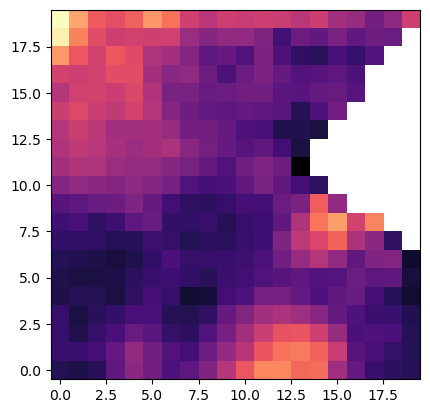

In [71]:
# lets take a cutout and plot it? 

cutout = data [20:40, 50:70]

fig, ax = plt.subplots()
plt.imshow(cutout, origin='lower', cmap='magma')

#lets save a new fits file for this cutout?
hdu=fits.PrimaryHDU(cutout)
hdu.writeto('data/2d/cutout.fits', overwrite=True)

